In [203]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datasets import load_dataset

# loading Datasets
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skil_list: ast.literal_eval(skil_list) if pd.notna(skil_list) else skil_list)

In [204]:
df_US = df[df['job_country'] == 'United States'].dropna(subset=['salary_year_avg'])

In [ ]:
df_DA_US = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]
df_DA_US = df_DA_US.dropna(subset=['salary_year_avg'])




4350

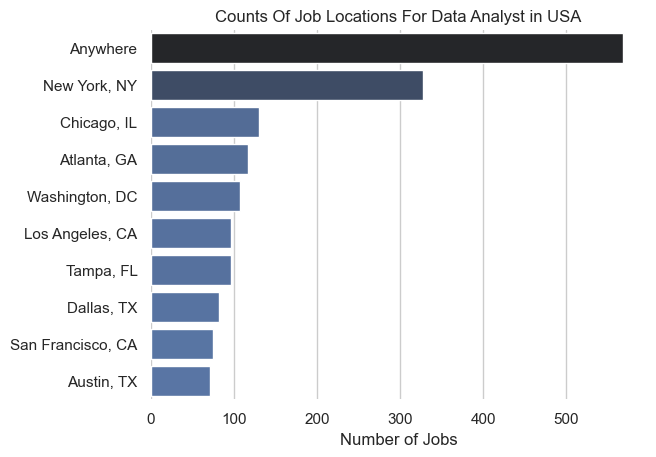

In [206]:
df_location_Plot = df_DA_US['job_location'].value_counts().head(10).to_frame()
sns.set_theme(style='whitegrid')
sns.barplot(data=df_location_Plot, x='count', y=df_location_Plot.index, hue='count', palette='dark:b_r', legend=False)
sns.despine(left=True, bottom=True)
plt.title('Counts Of Job Locations For Data Analyst in USA')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()

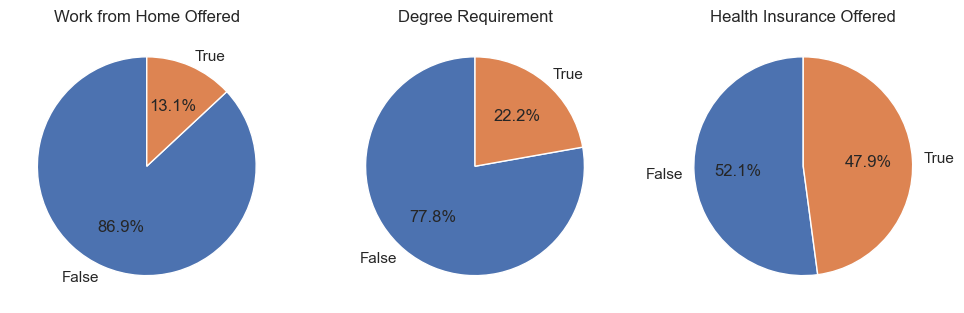

In [207]:
# rewrite the above with a for loop
dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

fig, ax = plt.subplots(1, 3)
fig.set_size_inches((12, 5))

for i, (column, title) in enumerate(dict_column.items()):
    ax[i].pie(df_DA_US[column].value_counts(), labels=['False', 'True'], autopct='%1.1f%%', startangle=90)
    ax[i].set_title(title)

plt.show()

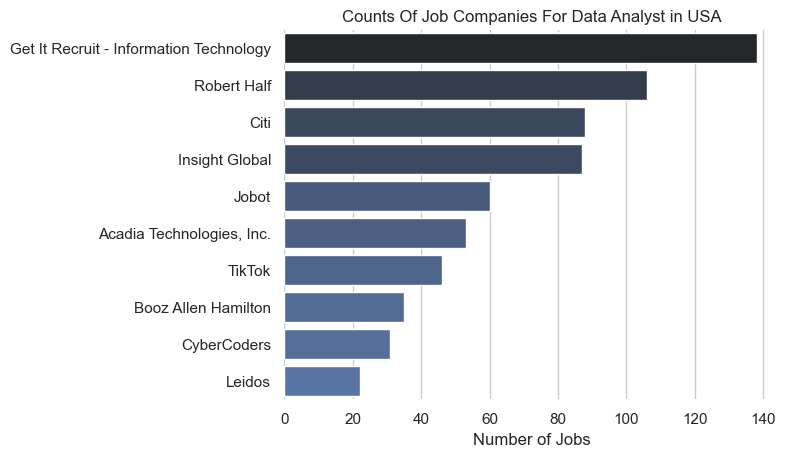

In [208]:
df_company_name_Plot = df_DA_US['company_name'].value_counts().head(10).to_frame()
sns.barplot(data=df_company_name_Plot, x='count', y=df_company_name_Plot.index, hue='count', palette='dark:b_r', legend=False)
sns.despine(left=True, bottom=True)
plt.title('Counts Of Job Companies For Data Analyst in USA')
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()

In [209]:
df_US_skills = df_US.explode('job_skills')
df_US_skills[['job_title', 'job_skills']]

,job_title,job_skills
92,Remote - Data Engineer - Permanent - W2,sql
92,Remote - Data Engineer - Permanent - W2,python
100,"Data Scientist, Risk Data Mining - USDS",sql
100,"Data Scientist, Risk Data Mining - USDS",r
100,"Data Scientist, Risk Data Mining - USDS",python
...,...,...
785648,Director Data Scientist - Commercial Platforms...,snowflake
785648,Director Data Scientist - Commercial Platforms...,spark
785692,Data Scientist- Hybrid Work Location,python
785692,Data Scientist- Hybrid Work Location,matlab


In [210]:
df_US_skills_COUNT = df_US_skills.groupby(['job_title_short', 'job_skills']).size()
df_US_skills_COUNT = df_US_skills_COUNT.reset_index(name='skill_count')
df_US_skills_COUNT.sort_values(by='skill_count', ascending=False, inplace=True)
df_US_skills_COUNT

,job_title_short,job_skills,skill_count
595,Data Scientist,python,3358
267,Data Analyst,sql,2508
626,Data Scientist,sql,2463
442,Data Engineer,sql,2110
599,Data Scientist,r,2053
...,...,...,...
63,Business Analyst,scikit-learn,1
18,Business Analyst,electron,1
1220,Software Engineer,julia,1
1289,Software Engineer,workfront,1


In [211]:
job_titles = df_US_skills_COUNT['job_title_short'].unique().tolist()
job_titles =  sorted(job_titles[:3])
job_titles2 = df_US_skills_COUNT['job_title_short'].unique().tolist()
job_titles2 =  sorted(job_titles2[:6])
job_titles2

['Data Analyst',
 'Data Engineer',
 'Data Scientist',
 'Senior Data Analyst',
 'Senior Data Engineer',
 'Senior Data Scientist']

C:\Users\w\AppData\Local\Temp\ipykernel_19916\3721762057.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend().set_visible(False)
C:\Users\w\AppData\Local\Temp\ipykernel_19916\3721762057.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend().set_visible(False)
C:\Users\w\AppData\Local\Temp\ipykernel_19916\3721762057.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend().set_visible(False)


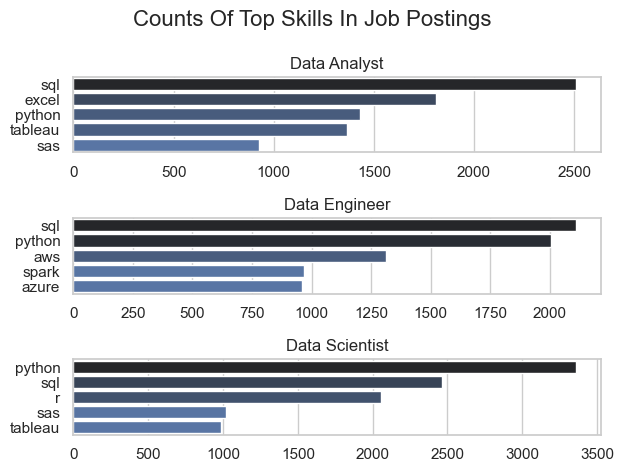

In [212]:
fig, ax = plt.subplots(len(job_titles), 1)
for i, job_title in enumerate(job_titles):
    df_plot = df_US_skills_COUNT[df_US_skills_COUNT['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='skill_count', y='job_skills', hue='skill_count', palette='dark:b_r', legend=False, ax=ax[i])
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    fig.suptitle('Counts Of Top Skills In Job Postings', fontsize=16)
    fig.tight_layout()

In [213]:
df_US_job_total_COUNT = df_US['job_title_short'].value_counts().reset_index(name='jobs_total')

In [214]:
df_US_skills_perc = pd.merge(df_US_skills_COUNT, df_US_job_total_COUNT, how='left', on='job_title_short')
df_US_skills_perc['%skill'] = df_US_skills_perc['skill_count'] / df_US_skills_perc['jobs_total'] * 100
df_US_skills_perc

,job_title_short,job_skills,skill_count,jobs_total,%skill
0,Data Scientist,python,3358,4553,73.753569
1,Data Analyst,sql,2508,4350,57.655172
2,Data Scientist,sql,2463,4553,54.096200
3,Data Engineer,sql,2110,2915,72.384220
4,Data Scientist,r,2053,4553,45.091149
...,...,...,...,...,...
1285,Business Analyst,scikit-learn,1,431,0.232019
1286,Business Analyst,electron,1,431,0.232019
1287,Software Engineer,julia,1,157,0.636943
1288,Software Engineer,workfront,1,157,0.636943


C:\Users\w\AppData\Local\Temp\ipykernel_19916\2161997167.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend().set_visible(False)
C:\Users\w\AppData\Local\Temp\ipykernel_19916\2161997167.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend().set_visible(False)
C:\Users\w\AppData\Local\Temp\ipykernel_19916\2161997167.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend().set_visible(False)


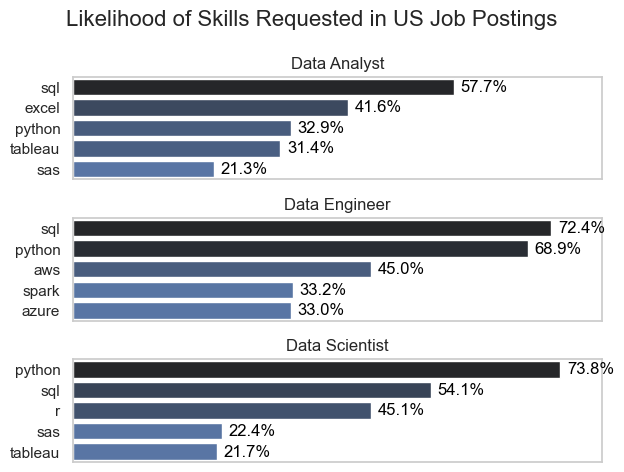

In [215]:
fig, ax = plt.subplots(len(job_titles), 1)
for i, job_title in enumerate(job_titles):
    df_plot = df_US_skills_perc[df_US_skills_perc['job_title_short'] == job_title].head(5)
    sns.barplot(data=df_plot, x='%skill', y='job_skills', hue='skill_count', palette='dark:b_r', legend=False, ax=ax[i])
    ax[i].set_title(job_title)
    ax[i].set_ylabel('')
    ax[i].set_xlabel('')
    ax[i].legend().set_visible(False)
    ax[i].set_xlim(0, 80)
    ax[i].set_xticks([])
    
    for n, v in enumerate(df_plot['%skill']):
        ax[i].text(v + 1, n, f"{v:.1f}%", color='black', va='center')
    fig.suptitle('Likelihood of Skills Requested in US Job Postings', fontsize=16)
    fig.tight_layout()
plt.show()

In [216]:
df_DA_US['job_posted_month_NUM'] = df_DA_US['job_posted_date'].dt.month
df_DA_US_exp = df_DA_US.explode('job_skills')

In [217]:
df_DA_US_PIVOT =df_DA_US_exp.pivot_table(index='job_posted_month_NUM', columns='job_skills', aggfunc= 'size', fill_value=0)
df_DA_US_PIVOT.loc['total'] = df_DA_US_PIVOT.sum()
df_DA_US_PIVOT = df_DA_US_PIVOT[df_DA_US_PIVOT.loc['total'].sort_values(ascending=False).index]
df_DA_US_PIVOT.drop('total')

job_skills,sql,excel,python,tableau,sas,r,power bi,powerpoint,word,sql server,...,no-sql,hugging face,solidity,selenium,ruby on rails,theano,typescript,vmware,vue,wrike
job_posted_month_NUM,,,,,,,,,,,,,,,,,,,,,
1,256,197,137,138,86,88,88,60,43,39,...,0,0,0,0,1,0,0,0,0,0
2,212,145,114,108,76,72,80,35,28,28,...,0,0,0,0,0,0,0,0,0,0
3,224,165,130,114,68,79,73,36,34,20,...,1,0,0,0,0,0,0,1,0,0
4,210,159,112,106,92,76,72,33,33,29,...,0,0,0,0,0,0,0,0,0,1
5,217,169,114,110,70,69,67,35,41,34,...,0,0,0,0,0,0,0,0,0,0
6,259,177,154,146,96,91,97,53,61,21,...,0,0,0,0,0,0,0,0,0,0
7,256,159,140,131,88,83,56,45,40,24,...,0,0,0,1,0,0,0,0,0,0
8,261,169,162,152,110,105,88,45,44,28,...,0,0,0,0,0,0,0,0,0,0
9,149,114,82,94,64,51,47,26,27,12,...,0,0,0,0,0,0,0,0,0,0


In [218]:
da_totals = df_DA_US.groupby('job_posted_month_NUM').size()

In [219]:
df_DA_US_prc = df_DA_US_PIVOT.div(da_totals/100, axis=0)
df_DA_US_prc

job_skills,sql,excel,python,tableau,sas,r,power bi,powerpoint,word,sql server,...,no-sql,hugging face,solidity,selenium,ruby on rails,theano,typescript,vmware,vue,wrike
job_posted_month_NUM,,,,,,,,,,,,,,,,,,,,,
1,56.140351,43.201754,30.043860,30.263158,18.859649,19.298246,19.298246,13.157895,9.429825,8.552632,...,0.00000,0.000000,0.000000,0.000000,0.219298,0.000000,0.000000,0.00000,0.000000,0.000000
2,62.170088,42.521994,33.431085,31.671554,22.287390,21.114370,23.460411,10.263930,8.211144,8.211144,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
3,60.540541,44.594595,35.135135,30.810811,18.378378,21.351351,19.729730,9.729730,9.189189,5.405405,...,0.27027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.27027,0.000000,0.000000
4,58.823529,44.537815,31.372549,29.691877,25.770308,21.288515,20.168067,9.243697,9.243697,8.123249,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.280112
5,64.201183,50.000000,33.727811,32.544379,20.710059,20.414201,19.822485,10.355030,12.130178,10.059172,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
6,58.465011,39.954853,34.762980,32.957111,21.670429,20.541761,21.896163,11.963883,13.769752,4.740406,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
7,61.835749,38.405797,33.816425,31.642512,21.256039,20.048309,13.526570,10.869565,9.661836,5.797101,...,0.00000,0.000000,0.000000,0.241546,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
8,59.589041,38.584475,36.986301,34.703196,25.114155,23.972603,20.091324,10.273973,10.045662,6.392694,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
9,57.088123,43.678161,31.417625,36.015326,24.521073,19.540230,18.007663,9.961686,10.344828,4.597701,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


In [220]:
# Remove the 'total' row using the index before further processing
df_DA_US_prc = df_DA_US_prc[df_DA_US_prc.index != 'total']
df_DA_US_prc['job_posted_month'] = df_DA_US_prc.index.map(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_US_prc = df_DA_US_prc.set_index('job_posted_month')
df_DA_US_prc


C:\Users\w\AppData\Local\Temp\ipykernel_19916\3142724741.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_DA_US_prc['job_posted_month'] = df_DA_US_prc.index.map(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))


job_skills,sql,excel,python,tableau,sas,r,power bi,powerpoint,word,sql server,...,no-sql,hugging face,solidity,selenium,ruby on rails,theano,typescript,vmware,vue,wrike
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,56.140351,43.201754,30.043860,30.263158,18.859649,19.298246,19.298246,13.157895,9.429825,8.552632,...,0.00000,0.000000,0.000000,0.000000,0.219298,0.000000,0.000000,0.00000,0.000000,0.000000
Feb,62.170088,42.521994,33.431085,31.671554,22.287390,21.114370,23.460411,10.263930,8.211144,8.211144,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Mar,60.540541,44.594595,35.135135,30.810811,18.378378,21.351351,19.729730,9.729730,9.189189,5.405405,...,0.27027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.27027,0.000000,0.000000
Apr,58.823529,44.537815,31.372549,29.691877,25.770308,21.288515,20.168067,9.243697,9.243697,8.123249,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.280112
May,64.201183,50.000000,33.727811,32.544379,20.710059,20.414201,19.822485,10.355030,12.130178,10.059172,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Jun,58.465011,39.954853,34.762980,32.957111,21.670429,20.541761,21.896163,11.963883,13.769752,4.740406,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Jul,61.835749,38.405797,33.816425,31.642512,21.256039,20.048309,13.526570,10.869565,9.661836,5.797101,...,0.00000,0.000000,0.000000,0.241546,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Aug,59.589041,38.584475,36.986301,34.703196,25.114155,23.972603,20.091324,10.273973,10.045662,6.392694,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Sep,57.088123,43.678161,31.417625,36.015326,24.521073,19.540230,18.007663,9.961686,10.344828,4.597701,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000


In [221]:
df_DA_US_prc_PLOT = df_DA_US_prc.iloc[ : , : 5]

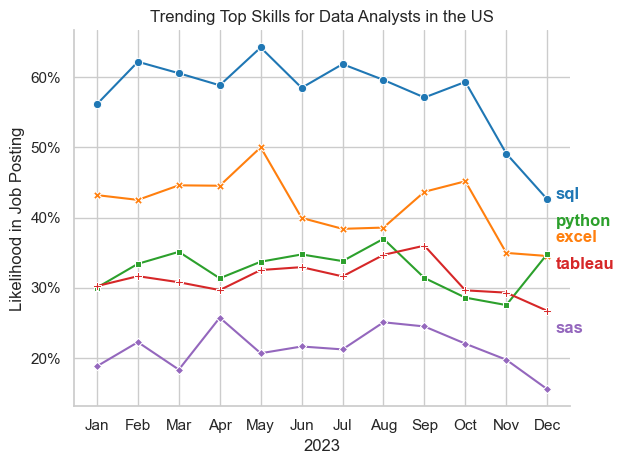

In [222]:
#fig, ax = plt.subplots()
sns.lineplot(data=df_DA_US_prc_PLOT, dashes=False, palette='tab10', markers=True)
sns.set_theme(style='ticks')
sns.despine()
plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
#ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
ax = plt.gca()
#ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))
from matplotlib.ticker import PercentFormatter
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

colors =['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i in range(5):
    y = df_DA_US_prc_PLOT.iloc[-1, i]
    plt.text(11.2, y + (i * 2), df_DA_US_prc_PLOT.columns[i] , color=colors[i], fontweight='bold')


plt.tight_layout()
plt.show()

In [223]:
df_US_TOP6 = df_US[df_US['job_title_short'].isin(job_titles2)]
df_US_TOP6_jobORDER = df_US_TOP6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

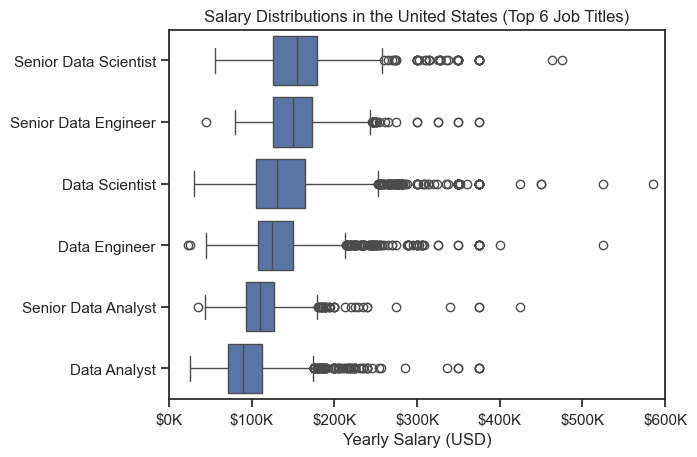

In [224]:
sns.boxplot(data=df_US_TOP6, x='salary_year_avg', y='job_title_short', order=df_US_TOP6_jobORDER)

plt.title('Salary Distributions in the United States (Top 6 Job Titles)')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000) 
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()

In [225]:
df_DA_US = df_DA_US.explode('job_skills')

In [226]:
df_DA_US[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [227]:
df_DA_US_TOP_PAY = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['median', 'count']).sort_values(by='median', ascending=False)
df_DA_US_TOP_PAY = df_DA_US_TOP_PAY.head(10)
df_DA_US_TOP_PAY

,median,count
job_skills,,
dplyr,196250.0,2
bitbucket,189000.0,3
gitlab,186000.0,3
solidity,179000.0,1
hugging face,175000.0,1
couchbase,160515.0,1
ansible,159640.0,1
mxnet,149000.0,2
cassandra,148250.0,6


In [228]:
df_DA_US_TOP_popular = df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['median', 'count']).sort_values(by='count', ascending=False)
df_DA_US_TOP_POPULAR = df_DA_US_TOP_popular.head(10)
df_DA_US_TOP_POPULAR

,median,count
job_skills,,
sql,91000.00,2508
excel,84392.00,1808
python,97500.00,1431
tableau,92875.00,1364
sas,90000.00,926
r,92500.00,893
power bi,90000.00,838
powerpoint,85000.00,462
word,81194.75,461


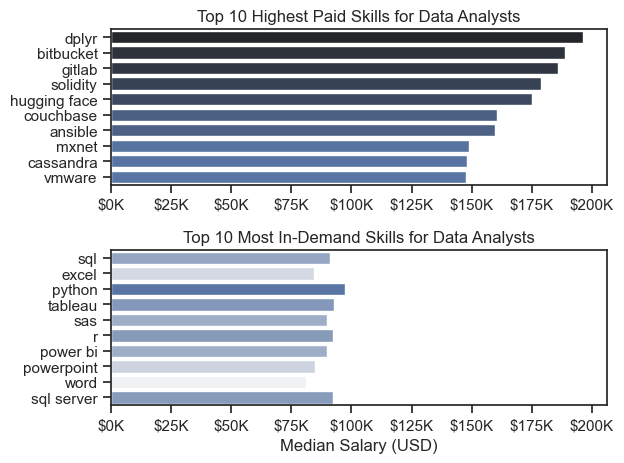

In [229]:
fig, ax = plt.subplots(2, 1) 
sns.set_theme(style="whitegrid")

# Top 10 Highest Paid Skills for Data Analysts
sns.barplot(data=df_DA_US_TOP_PAY, x='median', y=df_DA_US_TOP_PAY.index, ax=ax[0], hue='median', palette='dark:b_r' )
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[0].legend().remove()

# Top 10 Most In-Demand Skills for Data Analysts
sns.barplot(data=df_DA_US_TOP_POPULAR, x='median', y=df_DA_US_TOP_POPULAR.index, ax=ax[1], hue='median', palette='light:b' )
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')
ax[1].set_xlim(ax[0].get_xlim())  # Set the same x-axis limits as the first plot
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))
ax[1].legend().remove()

plt.tight_layout()
plt.show()

In [263]:
df_DA_US1 = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]
df_DA_US1 = df_DA_US1.dropna(subset=['salary_year_avg'])
df_DA_US1_exp = df_DA_US1.explode('job_skills')
len(df_DA_US1)

4350

In [265]:
df_DA_US1_exp[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [268]:
df_DA_US1_Skills = df_DA_US1_exp.groupby('job_skills')['salary_year_avg'].agg(['median', 'count']).sort_values(by='count', ascending=False)
df_DA_US1_Skills = df_DA_US1_Skills.rename(columns={'median': 'Median Salary', 'count': 'Job Postings'})


In [ ]:
df_DA_US1_Skills['Job Postings Percentage'] = (df_DA_US1_Skills['Job Postings'] / len(df_DA_US1)) * 100

4350

In [272]:
skill_limit = 5

df_DA_US1_skills_high_demand = df_DA_US1_Skills[df_DA_US1_Skills['Job Postings Percentage'] > skill_limit]
df_DA_US1_skills_high_demand

,Median Salary,Job Postings,Job Postings Percentage
job_skills,,,
sql,91000.00,2508,57.655172
excel,84392.00,1808,41.563218
python,97500.00,1431,32.896552
tableau,92875.00,1364,31.356322
sas,90000.00,926,21.287356
r,92500.00,893,20.528736
power bi,90000.00,838,19.264368
powerpoint,85000.00,462,10.620690
word,81194.75,461,10.597701


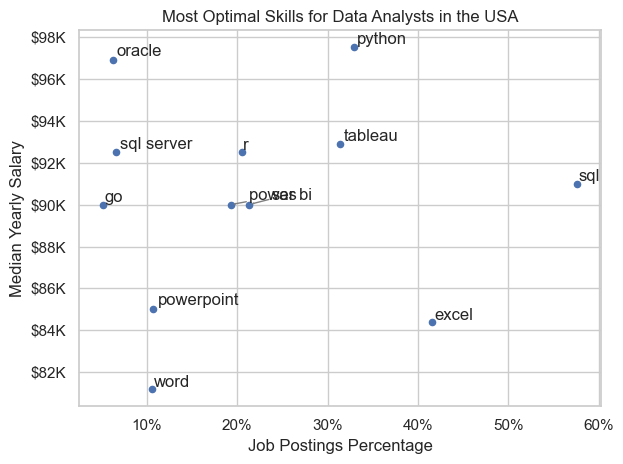

In [280]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

df_DA_US1_skills_high_demand.plot(kind='scatter', x='Job Postings Percentage', y='Median Salary')
texts = []
for i, txt in enumerate(df_DA_US1_skills_high_demand.index):
   texts.append(plt.text(df_DA_US1_skills_high_demand['Job Postings Percentage'].iloc[i] , df_DA_US1_skills_high_demand['Median Salary'].iloc[i] ,txt))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.xlabel('Job Postings Percentage')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the USA')
plt.tight_layout()
plt.show()

In [281]:
df_technology = df['job_type_skills'].copy()

# remove duplicates
df_technology = df_technology.drop_duplicates()

# remove NaN values
df_technology = df_technology.dropna()

# combine all dictionaries into one
technology_dict = {}
for row in df_technology:
    row_dict = ast.literal_eval(row)  # convert string to dictionary
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology_dict, add value to existing value
            technology_dict[key] += value
        else:                       # if key does not exist in technology_dict, add key and value
            technology_dict[key] = value

# remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

technology_dict

{'analyst_tools': ['power bi',
  'spreadsheet',
  'cognos',
  'powerbi',
  'powerpoint',
  'sharepoint',
  'ssrs',
  'microstrategy',
  'splunk',
  'dax',
  'sap',
  'sheets',
  'outlook',
  'visio',
  'ssis',
  'alteryx',
  'ms access',
  'msaccess',
  'word',
  'sas',
  'excel',
  'tableau',
  'datarobot',
  'nuix',
  'qlik',
  'esquisse',
  'spss',
  'looker'],
 'programming': ['vb.net',
  'pascal',
  'c',
  'visual basic',
  'java',
  'go',
  'swift',
  'erlang',
  'clojure',
  'crystal',
  'javascript',
  'apl',
  'kotlin',
  'vba',
  'sass',
  'scala',
  'f#',
  'assembly',
  'lisp',
  'haskell',
  'c#',
  'ocaml',
  'python',
  'groovy',
  'mongo',
  'php',
  'c++',
  'fortran',
  'visualbasic',
  'objective-c',
  'html',
  'delphi',
  'mongodb',
  'ruby',
  'shell',
  'r',
  'nosql',
  'cobol',
  'rust',
  'golang',
  't-sql',
  'no-sql',
  'sas',
  'perl',
  'matlab',
  'powershell',
  'julia',
  'sql',
  'dart',
  'typescript',
  'bash',
  'lua',
  'elixir',
  'solidity',
  '

In [283]:
df_technology = pd.DataFrame(list(technology_dict.items()), columns=['technology', 'skills'])

df_technology = df_technology.explode('skills')

df_technology


,technology,skills
0,analyst_tools,power bi
0,analyst_tools,spreadsheet
0,analyst_tools,cognos
0,analyst_tools,powerbi
0,analyst_tools,powerpoint
...,...,...
9,sync,twilio
9,sync,google chat
9,sync,microsoft teams
9,sync,zoom


In [285]:
df_DA_US1_PLOT = df_DA_US1_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')

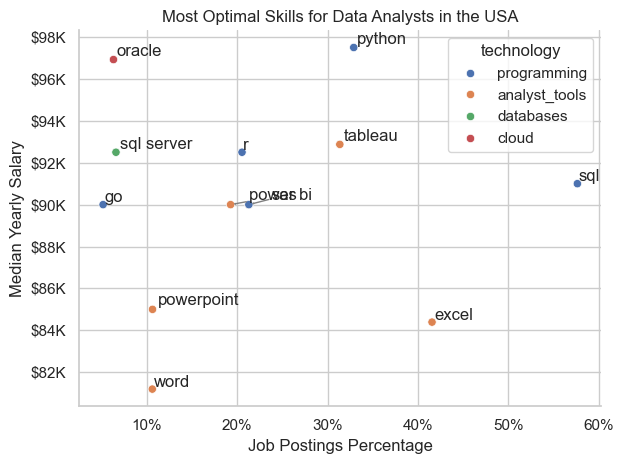

In [292]:
from adjustText import adjust_text
from matplotlib.ticker import PercentFormatter

#df_DA_US1_PLOT.plot(kind='scatter', x='Job Postings Percentage', y='Median Salary')
sns.scatterplot(data=df_DA_US1_PLOT, x='Job Postings Percentage', y='Median Salary', hue='technology')
sns.set_theme(style='ticks')
sns.despine()
texts = []
for i, txt in enumerate(df_DA_US1_skills_high_demand.index):
   texts.append(plt.text(df_DA_US1_skills_high_demand['Job Postings Percentage'].iloc[i] , df_DA_US1_skills_high_demand['Median Salary'].iloc[i] ,txt))
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1))
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.xlabel('Job Postings Percentage')
plt.ylabel('Median Yearly Salary')
plt.title('Most Optimal Skills for Data Analysts in the USA')
plt.tight_layout()
plt.show()